In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Spotify2019.csv")
df.head()

,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,6v3KW9xbzN5yKLt9YKDYA,Señorita,Shawn Mendes,0.759,0.548,9.0,-6.049,0.0,0.0290,0.0392,0.00,0.0828,0.749,116.967,190800.0,4.0
1,2Fxmhks0bxGSBdJ92vM42,bad guy,Billie Eilish,0.701,0.425,7.0,-10.965,1.0,0.3750,0.3280,0.13,0.1000,0.562,135.128,194088.0,4.0
2,0RiRZpuVRbi7oqRdSMwhQ,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.755,0.522,2.0,-4.368,1.0,0.0575,0.5330,0.00,0.0685,0.925,89.960,157560.0,4.0
3,6ocbgoVGwYJhOv1GgI9Ns,7 rings,Ariana Grande,0.778,0.317,1.0,-10.732,0.0,0.3340,0.5920,0.00,0.0881,0.327,140.048,178627.0,4.0
4,2YpeDb67231RjR0MgVLzs,Old Town Road - Remix,Lil Nas X,0.878,0.619,6.0,-5.560,1.0,0.1020,0.0533,0.00,0.1130,0.639,136.041,157067.0,4.0


Machine learning is when computers learn patterns from data to make predictions without being programmed. It uses past data to predict future values. In this specific dataset we 

In [32]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     str    
 1   name              50 non-null     str    
 2   artists           50 non-null     str    
 3   danceability      50 non-null     float64
 4   energy            50 non-null     float64
 5   key               50 non-null     float64
 6   loudness          50 non-null     float64
 7   mode              50 non-null     float64
 8   speechiness       50 non-null     float64
 9   acousticness      50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     float64
 15  time_signature    50 non-null     float64
dtypes: float64(13), str(3)
memory usage: 6.4 KB


id                  0
name                0
artists             0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64

The dataset containes features like energy, loudness, tempo and danceability. Most of the columns are also complete without missing data. There's a good range for building the model. 

In [33]:
X = df[['energy', 'loudness', 'tempo']]   # 3 features
y = df['danceability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Coefficients:", model1.coef_)
print("Intercept:", model1.intercept_)

Coefficients: [0.27411498 0.00734545 0.00039723]
Intercept: 0.5536165769256871


Coeficcients show the relationship between each feature and danceability. A positive coefficient means the feature increases danceability and a negative coefficient means the feature decreases danceability. 

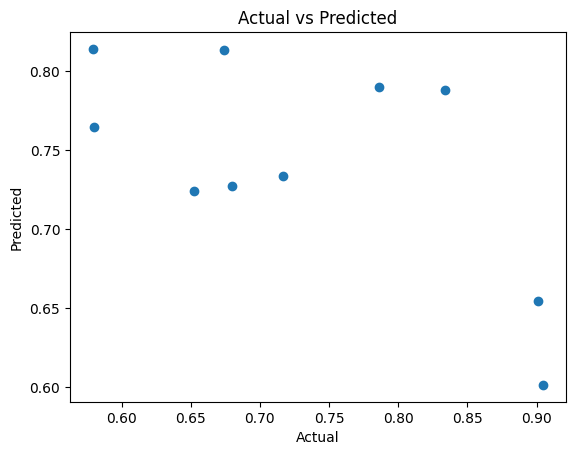

In [35]:
import matplotlib.pyplot as plt

y_pred1 = model1.predict(X_test)

plt.scatter(y_test, y_pred1)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

If the model has high accuracy the points should form a diagonal line. So predicted values match the actual values closely 

In [36]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.8, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

The accuracy is worse because the model has less training data so it can't learn patterns as well

In [37]:
X_all = df.select_dtypes(include=['float64', 'int64']).drop(columns=['danceability'])

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_all, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

Using more of the features tends to increase the accuracy since the model has more to learn from

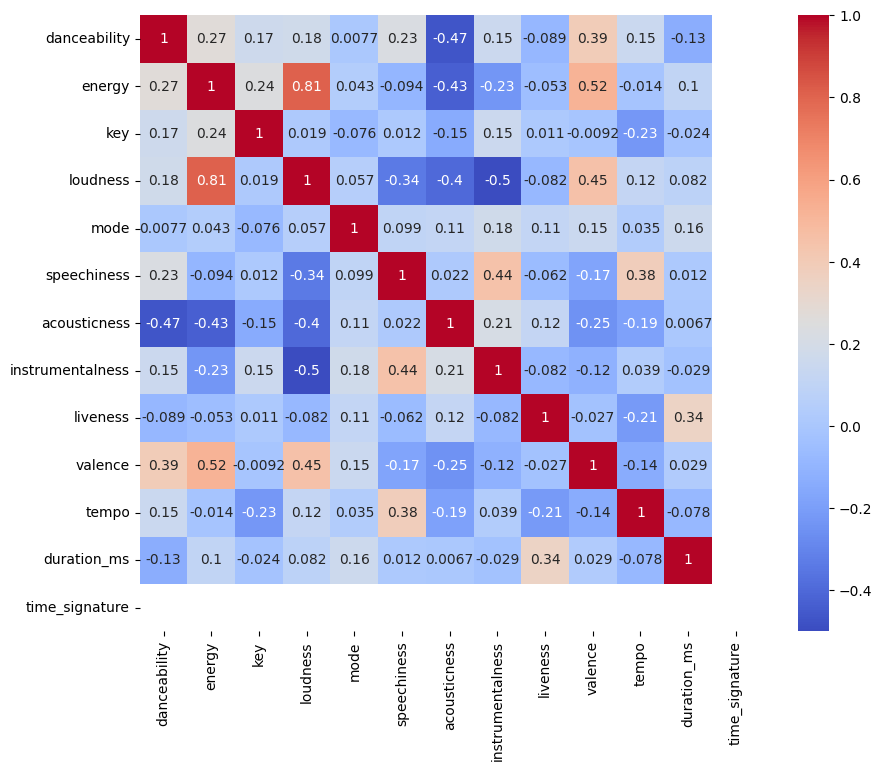

In [41]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Features like energy, loudness and tempo have a strong correlation with danceability. Strong correlations are close to -1 or 1 and it indicates that the feature is important so you know which ones to include in your model

A good model should make accurate predictions on unseen data and generalize well. It shouldn't be overfitting or underfitting. To improve the model we could clean the data or normalize it. 

In [39]:
from sklearn.metrics import r2_score, mean_squared_error

# Code for Model 1
r2_1 = r2_score(y_test, y_pred1)
mse_1 = mean_squared_error(y_test, y_pred1)

# Code for Model 2
r2_2 = r2_score(y_test2, y_pred2)
mse_2 = mean_squared_error(y_test2, y_pred2)

# Code for Model 3
r2_3 = r2_score(y_test3, y_pred3)
mse_3 = mean_squared_error(y_test3, y_pred3)

print("Model 1:", r2_1, mse_1)
print("Model 2:", r2_2, mse_2)
print("Model 3:", r2_3, mse_3)

Model 1: -1.0720520077626796 0.027144212830012348
Model 2: -0.47776290490779916 0.020495070638120873
Model 3: -2.1629623585597666 0.04143531297111032


In [40]:
results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "R^2": [r2_1, r2_2, r2_3],
    "MSE": [mse_1, mse_2, mse_3]
})

results

,Model,R^2,MSE
0,Model 1,-1.072052,0.027144
1,Model 2,-0.477763,0.020495
2,Model 3,-2.162962,0.041435


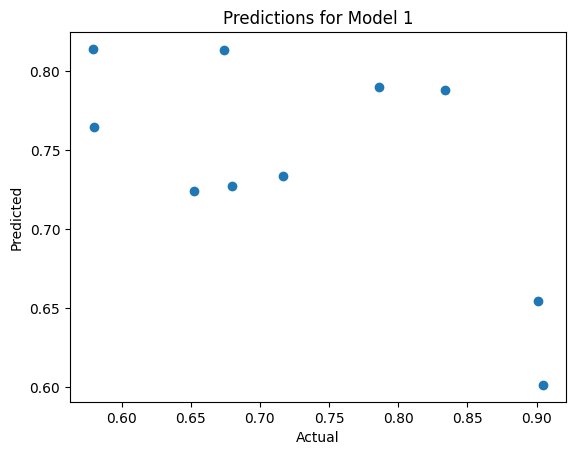

In [42]:
y_pred1 = model1.predict(X_test)

plt.scatter(y_test, y_pred1)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predictions for Model 1")
plt.show()